In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from feature_eng_functions import drop_unnecessary, occupation_mapping, summarize_workclass
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.under_sampling import RandomUnderSampler

In [2]:
base_adult = pd.read_csv(filepath_or_buffer="adult\\adult.data")
base_adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48838,64,?,321403,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


In [3]:
base_adult.drop(base_adult.loc[base_adult.workclass == " ?"].index, inplace=True)

In [4]:
base_adult.drop(base_adult.loc[base_adult.occupation == " ?"].index, inplace=True)

In [5]:
base_adult["occupation"] = base_adult["occupation"].apply(func=occupation_mapping)
base_adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Office-Worker,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Office-Worker,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Manual-Worker,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Manual-Worker,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Office-Worker,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33,Private,245211,Bachelors,13,Never-married,Office-Worker,Own-child,White,Male,0,0,40,United-States,<=50K
48837,39,Private,215419,Bachelors,13,Divorced,Office-Worker,Not-in-family,White,Female,0,0,36,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Office-Worker,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Office-Worker,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


In [6]:
#base_adult["workclass"] = base_adult["workclass"].apply(func=summarize_workclass)

In [7]:
base_adult = drop_unnecessary(df=base_adult)
base_adult

,age,workclass,fnlwgt,education-num,occupation,income
0,39,State-gov,77516,13,Office-Worker,<=50K
1,50,Self-emp-not-inc,83311,13,Office-Worker,<=50K
2,38,Private,215646,9,Manual-Worker,<=50K
3,53,Private,234721,7,Manual-Worker,<=50K
4,28,Private,338409,13,Office-Worker,<=50K
...,...,...,...,...,...,...
48836,33,Private,245211,13,Office-Worker,<=50K
48837,39,Private,215419,13,Office-Worker,<=50K
48839,38,Private,374983,13,Office-Worker,<=50K
48840,44,Private,83891,13,Office-Worker,<=50K


In [8]:
base_adult["occupation"].map(lambda x: str.strip(x))
base_adult["occupation"][0]

'Office-Worker'

In [9]:
X = base_adult.drop(columns=["income"])
y = base_adult["income"]

In [10]:
#income_replacer = {" <=50K": 0, " >50K": 1}
#y.replace(income_replacer, inplace=True)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train

,age,workclass,fnlwgt,education-num,occupation
12383,45,Private,199058,14,Office-Worker
373,45,Private,256649,9,Machinery-Worker
16518,49,Private,236586,9,Office-Worker
23163,41,Private,196456,14,Office-Worker
11630,22,Federal-gov,65547,10,Office-Worker
...,...,...,...,...,...
3237,30,Private,423770,10,Office-Worker
35537,52,Private,62834,9,Machinery-Worker
40206,51,Private,28978,10,Other-Service
23756,34,Private,345705,13,Office-Worker


In [12]:
X_train, y_train = RandomUnderSampler().fit_resample(X_train, y_train)

In [13]:
cat_variables = ["workclass", "occupation"]
num_variables = ["age", "fnlwgt", "education-num"]

In [14]:
column_tranform = make_column_transformer(
    (StandardScaler(), num_variables),
    (OneHotEncoder(), cat_variables)
)

In [15]:
knn = KNeighborsClassifier()
knn_pipe = Pipeline(steps=[("colum_transforms", column_tranform), ("knn", knn)])

In [16]:
param_grid = {
    "knn__n_neighbors": [3, 5, 10, 15, 20, 25],
    "knn__weights": ["uniform", "distance"],
    "knn__algorithm": ["ball_tree", "kd_tree", "brute"],
    "knn__p": [1, 2]
}
knn_grid = GridSearchCV(knn_pipe, param_grid, cv=5, scoring='accuracy')

In [17]:
knn_grid.fit(X_train, y_train)
knn_grid.best_params_

c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\model_selection\_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\metrics\_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\User\anaconda3

{'knn__algorithm': 'kd_tree',
 'knn__n_neighbors': 25,
 'knn__p': 2,
 'knn__weights': 'uniform'}

In [18]:
scores_knn = cross_val_score(knn_grid, X_test, y_test, cv=5, scoring="accuracy")
scores_knn

c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\model_selection\_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\metrics\_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\User\anaconda3

array([0.76655809, 0.78990228, 0.79250407, 0.78815861, 0.78001086])

In [19]:
rf_clf = DecisionTreeClassifier(class_weight="balanced")
rf_pipe = Pipeline(steps=[("colum_transforms", column_tranform), ("rf_clf", rf_clf)])

In [20]:
param_grid = {
    "rf_clf__criterion": ["gini", "entropy", "log_loss"],
    "rf_clf__splitter": ["random", "best"]
}

fr_grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='accuracy')

In [21]:
fr_grid.fit(X_train, y_train)
fr_grid.best_params_

{'rf_clf__criterion': 'log_loss', 'rf_clf__splitter': 'best'}

In [22]:
scores_rf = cross_val_score(fr_grid, X_test, y_test, cv=5, scoring="accuracy")
scores_rf

array([0.72747014, 0.71715527, 0.70613797, 0.70885388, 0.72514938])

In [23]:
logistic_reg = LogisticRegression(class_weight="balanced")

logistic_pipe = Pipeline(steps=[
    ("colum_transform", column_tranform),
    ("logistic_reg", logistic_reg)
])

In [24]:
param_grid = {
    "logistic_reg__l1_ratio": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

logistic_grid = GridSearchCV(logistic_pipe, param_grid, cv=5, scoring="accuracy")
logistic_grid.fit(X=X_train, y=y_train)

c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when pena

,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'logistic_reg__l1_ratio': [0.0, 0.1, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('standardscaler', ...), ('onehotencoder', ...)]"


In [25]:
logistic_score = cross_val_score(logistic_grid, X_test, y_test, scoring="accuracy")
logistic_score

c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when pena

array([0.68566775, 0.70412595, 0.69473112, 0.70342205, 0.70450842])

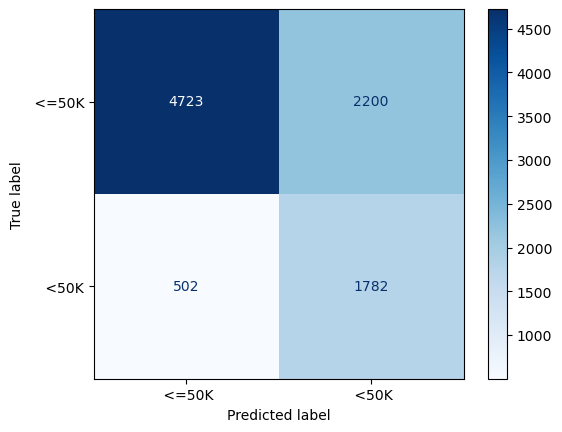

In [46]:
knn_disp = ConfusionMatrixDisplay.from_estimator(
    estimator=knn_grid,
    X=X_test,
    y=y_test,
    display_labels=[" <=50K", " <50K"],
    cmap=plt.cm.Blues
)

plt.show()

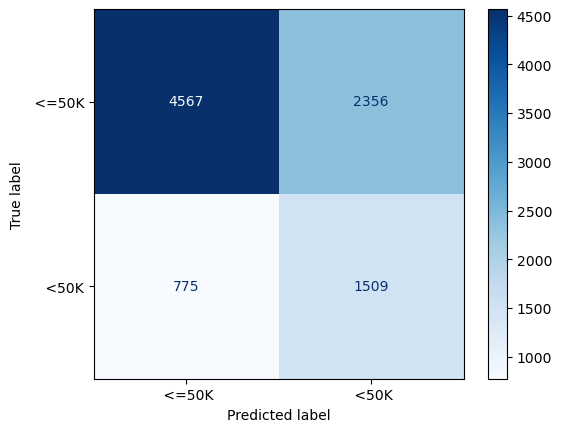

In [45]:
dt_disp = ConfusionMatrixDisplay.from_estimator(
    estimator=fr_grid,
    X=X_test,
    y=y_test,
    display_labels=[" <=50K", " <50K"],
    cmap=plt.cm.Blues
)

plt.show()

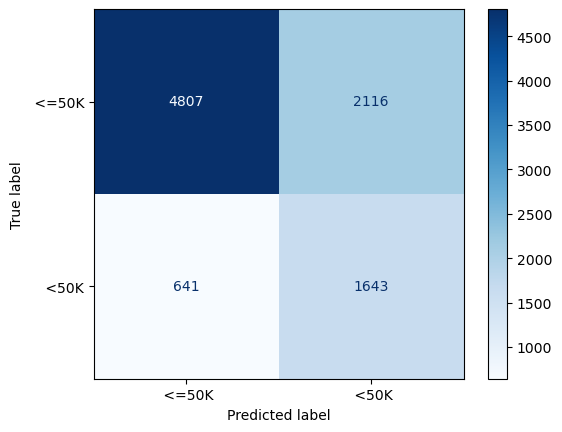

In [44]:
logistic_disp = ConfusionMatrixDisplay.from_estimator(
    estimator=logistic_grid,
    X=X_test,
    y=y_test,
    display_labels=[" <=50K", " <50K"],
    cmap=plt.cm.Blues
)

plt.show()

In [29]:
y_pred_knn = knn_grid.predict(X_test)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

       <=50K       0.90      0.68      0.78      6923
        >50K       0.45      0.78      0.57      2284

    accuracy                           0.71      9207
   macro avg       0.68      0.73      0.67      9207
weighted avg       0.79      0.71      0.73      9207



In [30]:
accuracy_score(y_test, y_pred_knn)

0.706527642011513

In [31]:
precision_score(y_test, y_pred_knn, pos_label=" >50K")

0.44751381215469616

In [32]:
recall_score(y_test, y_pred_knn, pos_label=" >50K")

0.7802101576182137

In [33]:
f1_score(y_test, y_pred_knn, pos_label=" >50K")

0.5687839131822534

In [34]:
y_pred_dt = fr_grid.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

       <=50K       0.85      0.66      0.74      6923
        >50K       0.39      0.66      0.49      2284

    accuracy                           0.66      9207
   macro avg       0.62      0.66      0.62      9207
weighted avg       0.74      0.66      0.68      9207



In [35]:
accuracy_score(y_test, y_pred_dt)

0.6599326599326599

In [36]:
precision_score(y_test, y_pred_dt, pos_label=" >50K")

0.3904269081500647

In [37]:
recall_score(y_test, y_pred_dt, pos_label=" >50K")

0.6606830122591943

In [38]:
f1_score(y_test, y_pred_dt, pos_label=" >50K")

0.49081151406732804

In [39]:
y_pred_logistic = logistic_grid.predict(X_test)
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

       <=50K       0.88      0.69      0.78      6923
        >50K       0.44      0.72      0.54      2284

    accuracy                           0.70      9207
   macro avg       0.66      0.71      0.66      9207
weighted avg       0.77      0.70      0.72      9207



In [40]:
accuracy_score(y_test, y_pred_logistic)

0.7005539263603779

In [41]:
precision_score(y_test, y_pred_logistic, pos_label=" >50K")

0.43708433093907956

In [42]:
recall_score(y_test, y_pred_logistic, pos_label=" >50K")

0.7193520140105079

In [43]:
f1_score(y_test, y_pred_logistic, pos_label=" >50K")

0.5437696508356776